In [1]:
# 환경 설정
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH15-Agents")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH15-Agents


## 1. 사용자 툴을 생성

In [3]:
from langchain.tools import tool
from typing import List, Dict, Annotated
from langchain_teddynote.tools import GoogleNews
from langchain_experimental.utilities import PythonREPL


# 도구 생성
@tool
def search_news(query: str) -> List[Dict[str, str]]:
    """Search Google News by input keyword"""
    news_tool = GoogleNews()
    return news_tool.search_by_keyword(query, k=5)


# 도구 생성
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    result = ""
    try:
        result = PythonREPL().run(code)
    except BaseException as e:
        print(f"Failed to execute. Error: {repr(e)}")
    finally:
        return result


도구 이름: search_news
도구 설명: Search Google News by input keyword
도구 이름: python_repl_tool
도구 설명: Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.


## 2. 사용자 툴을 검증(동작)

In [7]:
print(f"도구 이름: {search_news.name}")
print(f"도구 설명: {search_news.description}")
print(f"도구 이름: {python_repl_tool.name}")
print(f"도구 설명: {python_repl_tool.description}")

도구 이름: search_news
도구 설명: Search Google News by input keyword
도구 이름: python_repl_tool
도구 설명: Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.


In [4]:
print(search_news("구글 제미나이"))

C:\Users\SBA\AppData\Local\Temp\ipykernel_14608\4148259175.py:1: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  print(search_news("구글 제미나이"))


[{'url': 'https://news.google.com/rss/articles/CBMiVkFVX3lxTFB0SnBlYlBlOFpscnF3R2pmMlllT1hfRWdJNndYeTNJMU9USFZPTXU4Qzc2TTJGU0FJQzgyWFc3VEQ0RHpYaWU4ZVhCR3hWOUwta0ZQM29n?oc=5', 'content': "AI '공짜 시대' 막 내리나…구글 제미나이, 요금제별 혜택·한도 공식화 - 지디넷코리아"}, {'url': 'https://news.google.com/rss/articles/CBMib0FVX3lxTE5DaHMtbkdkbksxeGc0NUUwbW54OG12b0xqME4tZksxVW85WWJDaFlQVG9KREJqcVNrNGRFUTZacVRJWGlfUm5ZemM4TjZ1bF9TZHlnNXRDc2xLSDBnTmowbFYtNkdOZU5pLXJqS2dRWdIBZkFVX3lxTFA5cTNZR2p5UDh2R0FCSnMydTExOGFidngtSy1WU2lFZ0Z2QXhYckJwNXdrbkROUXZRcnhyYnNEZXZKMFFSQnNPRWJ3ZXFVQXRDN1dyemN5dU51LUZ1Rm5BY3lIdUF0dw?oc=5', 'content': '‘검색 왕국’ 구글, 제미나이 기반 ‘AI 모드’ 한국어 지원 시작…네이버 아성 흔드나 - 동아일보'}, {'url': 'https://news.google.com/rss/articles/CBMiU0FVX3lxTE82cXNwVU92X0FoMm5QRTZYbllLZkJYOTA2d0d2cmo4SjJrUDBMMDBiMXRSWl9WXzV5UDZZTWdNaGN1OXhSOVNtZDAtVEU1U0ZiSkFn0gFYQVVfeXFMTURlRG1KSjlKdUowVmpHd3RsTS1GUWFPdXZkejE1M2wtbGZqMjdXek9CakZsVjlwR05fTzN0MEVwSWVlMElmajZEQ3RkRUtjREV1LTRFYzJDbw?oc=5', 'content': '구글, AI 모드 한국어 공식 지원…복잡한 질문 척척 - SBS B

In [5]:
print(python_repl_tool("for i in range(3): print(i)"))

Python REPL can execute arbitrary code. Use with caution.


0
1
2



## 3. 사용자 툴을 리스트에 저장

In [8]:
# tools 정의
tools = [search_news, python_repl_tool]

## 4. Agent를 위한 프롬프트를 생성

일반 멀티턴 채팅과 다른 부분은 아래 agent_scratchpad가 추가된 부분

("placeholder", "{agent_scratchpad}"),

In [10]:
from langchain_core.prompts import ChatPromptTemplate

# 프롬프트 생성
# 프롬프트는 에이전트에게 모델이 수행할 작업을 설명하는 텍스트를 제공합니다. (도구의 이름과 역할을 입력)
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. "
            "Make sure to use the `search_news` tool for searching keyword related news.",
        ),
        ("placeholder", "{chat_history}"),
        ("human", "{input}"),
        ("placeholder", "{agent_scratchpad}"),
    ]
)

## 5. Agent 생성

In [11]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_tool_calling_agent

# LLM 정의
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Agent 생성
agent = create_tool_calling_agent(llm, tools, prompt)

## 6. AgentExecutor 생성

In [12]:
from langchain.agents import AgentExecutor

# AgentExecutor 생성
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    # Agent의 동작을 자세히 출력
    verbose=True,
    max_iterations=10,
    max_execution_time=10,
    handle_parsing_errors=True,
)

# AgentExecutor 실행
result = agent_executor.invoke({"input": "AI 투자와 관련된 뉴스를 검색해 주세요."})

print("Agent 실행 결과:")
print(result["output"])



> Entering new AgentExecutor chain...

Invoking: `search_news` with `{'query': 'AI 투자'}`


[{'url': 'https://news.google.com/rss/articles/CBMigwFBVV95cUxQVXQzb1lMdlA0M1haT2dCR1FRLS1OWWw1QlFpZ00wOUdaTzBKblZkMWtJM2sxalhOS1ZWR2o5SU9VaTN0R0l3bmpYZE4ycklacWktVm5TVGlDZ0d3TXZFS1RRMFZvOWh3djJoSTVQNFpWNF9PZEROcUl5c2pQNVd5OGFYNA?oc=5', 'content': "VC업계, 피지컬 AI·로봇 선점 경쟁...정책 리스크에 뜨는 '자동화' - 인베스트조선"}, {'url': 'https://news.google.com/rss/articles/CBMiYEFVX3lxTE5vUFFSQS1uWEowWVZKUWJmSGd3Rm1mendLeWU0blJtdFVMRDVER1JnTHBKc2MzZ1F5eUtaLVROSldDRXVwa0g5UFpzcE9tZkhlQlhGT3ZOVEc2UGJCdWgxXw?oc=5', 'content': '"8월 국내 벤처투자 1조원 돌파"…AI 쏠림 강화 - 아시아경제'}, {'url': 'https://news.google.com/rss/articles/CBMic0FVX3lxTE1TU0NCaDdMeW5Vampvc211MDRVM1VLaVRrc253YmZGU0lrekFPWVRxbnVaMl92Q3Q3bjZCSjYtcHJjUnkxVDhDNWYyNnc4ekgzNmZjZm9oQ2djMUtHeVd0aVRsRzZpSy1KbkZ3SjE4alFuc1E?oc=5', 'content': "빅테크 AI 인프라 '천문학적 투자' 경제효과 불투명, 고용 창출 기여도 낮아 - 비즈니스포스트"}, {'url': 'https://news.google.com/rss/articles/CBMic0FVX3lxTE5xY25HLTFNTXFzSnk5VC1qe

## Stream으로 진행 내용 출력

In [13]:
from langchain.agents import AgentExecutor

# AgentExecutor 생성
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=False,
    handle_parsing_errors=True,
)

In [14]:
# 스트리밍 모드로 실행합니다
result = agent_executor.stream({"input": "홀로라이브와 관련된 뉴스를 검색해 주세요."})

for step in result:
    # 중간 단계 출력
    print(step)
    print("===" * 20)

{'actions': [ToolAgentAction(tool='search_news', tool_input={'query': '홀로라이브'}, log="\nInvoking: `search_news` with `{'query': '홀로라이브'}`\n\n\n", message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_darG5oyfWqAK6Lc1UzGRrmtq', 'function': {'arguments': '{"query":"홀로라이브"}', 'name': 'search_news'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8bda4d3a2c', 'service_tier': 'default'}, id='run--238b3007-fc7c-4f65-8c30-12b28942dc2d', tool_calls=[{'name': 'search_news', 'args': {'query': '홀로라이브'}, 'id': 'call_darG5oyfWqAK6Lc1UzGRrmtq', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'search_news', 'args': '{"query":"홀로라이브"}', 'id': 'call_darG5oyfWqAK6Lc1UzGRrmtq', 'index': 0, 'type': 'tool_call_chunk'}])], tool_call_id='call_darG5oyfWqAK6Lc1UzGRrmtq')], 'messages': [AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_darG

In [15]:
from langchain_teddynote.messages import AgentStreamParser

agent_stream_parser = AgentStreamParser()

[도구 호출]
Tool: python_repl_tool
code: import matplotlib.pyplot as plt

# 데이터
sizes = [15, 30, 45, 10]
labels = ['A', 'B', 'C', 'D']
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Sample Pie Chart')
plt.show()
Log: 
Invoking: `python_repl_tool` with `{'code': "import matplotlib.pyplot as plt\n\n# 데이터\nsizes = [15, 30, 45, 10]\nlabels = ['A', 'B', 'C', 'D']\ncolors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']\n\n# 파이 차트 그리기\nplt.figure(figsize=(8, 6))\nplt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)\nplt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.\nplt.title('Sample Pie Chart')\nplt.show()"}`





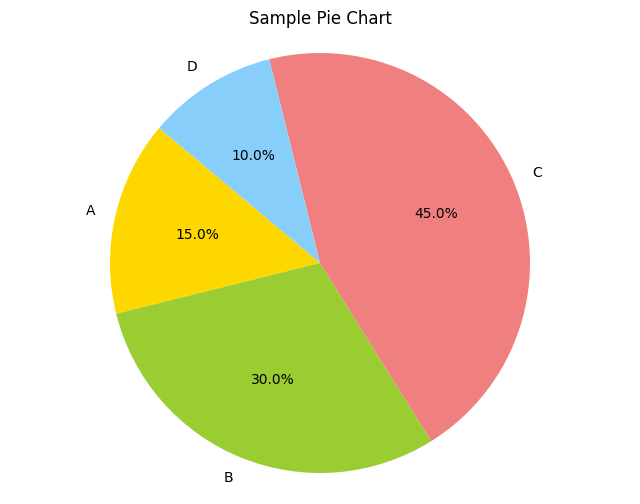

[관찰 내용]
Observation: 
[최종 답변]
파이 차트가 성공적으로 그려졌습니다. 차트는 각 섹션의 비율을 보여주며, 레이블과 색상이 포함되어 있습니다. 추가적인 질문이나 다른 요청이 있으시면 말씀해 주세요!


In [16]:
# 질의에 대한 답변을 스트리밍으로 출력 요청
result = agent_executor.stream(
    {"input": "matplotlib 을 사용하여 pie 차트를 그리는 코드를 작성하고 실행하세요."}
)

for step in result:
    # 중간 단계를 parser 를 사용하여 단계별로 출력
    # print(step)
    agent_stream_parser.process_agent_steps(step)

In [22]:
# AgentCallbacks와 AgentStreamParser를 langchain_teddynote.messages에서 가져옵니다.
from langchain_teddynote.messages import AgentCallbacks, AgentStreamParser


# 도구 호출 시 실행되는 콜백 함수입니다.
def tool_callback(tool) -> None:
    print("<<<<<<< 도구 호출 >>>>>>")
    print(f"Tool: {tool.get('tool')}")  # 사용된 도구의 이름을 출력합니다.
    print("<<<<<<< 도구 호출 >>>>>>")


# 관찰 결과를 출력하는 콜백 함수입니다.
def observation_callback(observation) -> None:
    print("<<<<<<< 관찰 내용 >>>>>>")
    for key, value in observation.items():
        print(f"Observation: {observation.get(key)}")  # 관찰 내용을 출력합니다.
    print("<<<<<<< 관찰 내용 >>>>>>")


# 최종 결과를 출력하는 콜백 함수입니다.
def result_callback(result: str) -> None:
    print("<<<<<<< 최종 답변 >>>>>>")
    print(result)  # 최종 답변을 출력합니다.
    print("<<<<<<< 최종 답변 >>>>>>")


# AgentCallbacks 객체를 생성하여 각 단계별 콜백 함수를 설정합니다.
agent_callbacks = AgentCallbacks(
    tool_callback=tool_callback,
    observation_callback=observation_callback,
    result_callback=result_callback,
)

# AgentStreamParser 객체를 생성하여 에이전트의 실행 과정을 파싱합니다.
agent_stream_parser = AgentStreamParser(agent_callbacks)

In [23]:
# 질의에 대한 답변을 스트리밍으로 출력 요청
result = agent_executor.stream({"input": "AI 투자관련 뉴스를 검색해 주세요."})

for step in result:
    # 중간 단계를 parser 를 사용하여 단계별로 출력
    agent_stream_parser.process_agent_steps(step)

<<<<<<< 도구 호출 >>>>>>
Tool: search_news
<<<<<<< 도구 호출 >>>>>>
<<<<<<< 관찰 내용 >>>>>>
Observation: [{'url': 'https://news.google.com/rss/articles/CBMigwFBVV95cUxQVXQzb1lMdlA0M1haT2dCR1FRLS1OWWw1QlFpZ00wOUdaTzBKblZkMWtJM2sxalhOS1ZWR2o5SU9VaTN0R0l3bmpYZE4ycklacWktVm5TVGlDZ0d3TXZFS1RRMFZvOWh3djJoSTVQNFpWNF9PZEROcUl5c2pQNVd5OGFYNA?oc=5', 'content': "VC업계, 피지컬 AI·로봇 선점 경쟁...정책 리스크에 뜨는 '자동화' - 인베스트조선"}, {'url': 'https://news.google.com/rss/articles/CBMiYEFVX3lxTE5vUFFSQS1uWEowWVZKUWJmSGd3Rm1mendLeWU0blJtdFVMRDVER1JnTHBKc2MzZ1F5eUtaLVROSldDRXVwa0g5UFpzcE9tZkhlQlhGT3ZOVEc2UGJCdWgxXw?oc=5', 'content': '"8월 국내 벤처투자 1조원 돌파"…AI 쏠림 강화 - 아시아경제'}, {'url': 'https://news.google.com/rss/articles/CBMic0FVX3lxTE1TU0NCaDdMeW5Vampvc211MDRVM1VLaVRrc253YmZGU0lrekFPWVRxbnVaMl92Q3Q3bjZCSjYtcHJjUnkxVDhDNWYyNnc4ekgzNmZjZm9oQ2djMUtHeVd0aVRsRzZpSy1KbkZ3SjE4alFuc1E?oc=5', 'content': "빅테크 AI 인프라 '천문학적 투자' 경제효과 불투명, 고용 창출 기여도 낮아 - 비즈니스포스트"}, {'url': 'https://news.google.com/rss/articles/CBMic0FVX3lxTE5xY25HLTFNTXFzSnk5VC1q

## 이전 대화 내용을 기억하는 Agent

In [24]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

# session_id 를 저장할 딕셔너리 생성
store = {}


# session_id 를 기반으로 세션 기록을 가져오는 함수
def get_session_history(session_ids):
    if session_ids not in store:  # session_id 가 store에 없는 경우
        # 새로운 ChatMessageHistory 객체를 생성하여 store에 저장
        store[session_ids] = ChatMessageHistory()
    return store[session_ids]  # 해당 세션 ID에 대한 세션 기록 반환


# 채팅 메시지 기록이 추가된 에이전트를 생성합니다.
agent_with_chat_history = RunnableWithMessageHistory(
    agent_executor,
    # 대화 session_id
    get_session_history,
    # 프롬프트의 질문이 입력되는 key: "input"
    input_messages_key="input",
    # 프롬프트의 메시지가 입력되는 key: "chat_history"
    history_messages_key="chat_history",
)

In [25]:
# 질의에 대한 답변을 스트리밍으로 출력 요청
response = agent_with_chat_history.stream(
    {"input": "구글 잼민이 최근 뉴스를 확인해줘"},
    # session_id 설정
    config={"configurable": {"session_id": "abc123"}},
)

# 출력 확인
for step in response:
    agent_stream_parser.process_agent_steps(step)

<<<<<<< 도구 호출 >>>>>>
Tool: search_news
<<<<<<< 도구 호출 >>>>>>
<<<<<<< 관찰 내용 >>>>>>
Observation: [{'url': 'https://news.google.com/rss/articles/CBMiYEFVX3lxTE9BRmgzc0xoV0E5b3FOX1B6WndqR29pYmNxOTdQdDV1T00tTTBFeWcweURVb3JMd0JWaHA2a055b05BSTdlc19VMmYweTFNd0FXemxUeEg0ZG01V3ppSzJ1SQ?oc=5', 'content': '구글, 제미나이 사용 한도 공개…무료·유료 차이 살펴보니 - 네이트'}, {'url': 'https://news.google.com/rss/articles/CBMi5gFBVV95cUxOcmI5b3kyN1A5WTFVQ3dpZmdybWhvYnVCVXktbXpPUTJldm80Rk4taGI4Qzl0T0diaDlFaFRKbnpHczlPcG1IUjdDVUEyMUkyQjVDSVpHbDVSeThad3hVeGVSR3lVdWZhanpIMlAxek5lUVduUEFVd3NQamZJV24tUklTZXZzOFp4djcxeEJJX1Vxa0tSWlhUWjFJQV9EQ3EyVTZhcUFlQ0RsajhPbHNRdko4WUt0QmRxekhmUnFiYTZXYnhoM2RLNEs2bFBHaEI5em0yWDlWVzd0aDEzX1FPYVBsVEFRQQ?oc=5', 'content': '구글 제미나이(Gemini)! 너 잼민이 아냐? - Smilegate.AI'}, {'url': 'https://news.google.com/rss/articles/CBMiakFVX3lxTE51N0hnYVhRNHk3bUtVY3JJUi11d0FCMkZfa3NFZDItMzNucGRsY0lsX0hZTDJwdkIzVWZkYzdtN0dHT2VmOHNycXNsbzZCdWhPczUtMmJmLXhuVFhXbG1lN0I4TlNsRjczLUE?oc=5', 'content': "구글, 개발자 터미널용 오픈 소스 AI 도구 '